# Coursera Course Dataset Analysis

## Executive Summary

- The cleaned dataset contains 891 Coursera course records and 6 analysis-ready columns.
- University of Pennsylvania appears most often, with 59 courses.
- Regular courses are the largest certificate type, with 582 records.
- Stanford University's `Machine Learning` course has the highest enrollment, with 3,200,000 students.
- Rating and enrollment have a very weak correlation of 0.0711.

## Dataset Description

This dataset contains Coursera course records from Kaggle. Each row represents one course or course offering, with information about the course title, organization, certificate type, rating, difficulty, and student enrollment. The raw file has 891 rows; after cleaning, the analysis uses 6 columns.

## Data Loading

The CSV file is loaded with Pandas so the analysis can be reproduced from the original data file.

In [1]:
from pathlib import Path

import pandas as pd

DATA_PATH = Path("../data/coursea_data.csv")
CLEANED_OUTPUT_PATH = Path("../outputs/coursera_courses_cleaned.csv")

raw_courses = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows: {raw_courses.shape[0]}")
print(f"Columns: {raw_courses.shape[1]}")

Dataset loaded successfully.
Rows: 891
Columns: 7


In [2]:
print("Before cleaning, two columns need attention:")
print("1. Unnamed: 0 is an old index column, so we will remove it.")
print("2. course_students_enrolled is stored as text, so we will convert it into a number.")

Before cleaning, two columns need attention:
1. Unnamed: 0 is an old index column, so we will remove it.
2. course_students_enrolled is stored as text, so we will convert it into a number.


## Cleaning Step 1: Review Column Names

First, we make the column names easier to understand before doing any analysis.

In [3]:
print("Column review complete: remove the old index column and rename unclear columns for readability.")

Column review complete: remove the old index column and rename unclear columns for readability.


In [4]:
courses = raw_courses.copy()

courses = courses.drop(columns=[courses.columns[0]])

courses = courses.rename(
    columns={
        "course_title": "course_title",
        "course_organization": "organization",
        "course_Certificate_type": "certificate_type",
        "course_rating": "rating",
        "course_difficulty": "difficulty",
        "course_students_enrolled": "students_enrolled_raw",
    }
)

print("Column names cleaned: old index removed and unclear names renamed.")

Column names cleaned: old index removed and unclear names renamed.


## Cleaning Step 2: Check Missing Values

We check whether any important information is blank. If nothing is missing, we can continue without filling or removing rows.

In [5]:
missing_count = int(courses.isna().sum().sum())

if missing_count == 0:
    print("Missing value check complete: no blank values were found.")
else:
    print(f"Missing value check complete: {missing_count} blank values found.")

Missing value check complete: no blank values were found.


## Cleaning Step 3: Check Duplicates

We check whether any full rows are repeated, then review repeated course titles separately because the same title can appear for different organizations or certificate types.

In [6]:
duplicate_row_count = int(courses.duplicated().sum())
duplicate_title_count = int(courses["course_title"].duplicated().sum())

print(f"Duplicate full rows: {duplicate_row_count}")
print(f"Repeated course titles: {duplicate_title_count}")

Duplicate full rows: 0
Repeated course titles: 3


In [7]:
duplicate_titles = (
    courses.loc[
        courses["course_title"].duplicated(keep=False),
        [
            "course_title",
            "organization",
            "certificate_type",
            "rating",
            "difficulty",
            "students_enrolled_raw",
        ],
    ]
    .sort_values("course_title")
    .reset_index(drop=True)
)

print("These course titles appear more than once, but they are not duplicate rows.")
print("They stay in the dataset because the organization or certificate type is different.")

duplicate_titles

These course titles appear more than once, but they are not duplicate rows.
They stay in the dataset because the organization or certificate type is different.


,course_title,organization,certificate_type,rating,difficulty,students_enrolled_raw
0,Developing Your Musicianship,Berklee College of Music,COURSE,4.8,Mixed,41k
1,Developing Your Musicianship,Berklee College of Music,SPECIALIZATION,4.8,Beginner,54k
2,Machine Learning,University of Washington,SPECIALIZATION,4.6,Intermediate,290k
3,Machine Learning,Stanford University,COURSE,4.9,Mixed,3.2m
4,Marketing Digital,Universidade de São Paulo,COURSE,4.8,Beginner,81k
5,Marketing Digital,Universidad Austral,SPECIALIZATION,4.7,Beginner,39k


## Cleaning Step 4: Convert Enrollment Counts

The enrollment column is written as text, such as `5.3k` and `130k`. We convert it into a number so it can be used for sorting, summaries, and charts.

In [8]:
def parse_enrollment(value):
    """Convert Coursera enrollment text into a whole number."""
    text_value = str(value).strip().lower().replace(",", "")

    if text_value.endswith("k"):
        return int(float(text_value[:-1]) * 1_000)

    if text_value.endswith("m"):
        return int(float(text_value[:-1]) * 1_000_000)

    return int(float(text_value))


courses["students_enrolled"] = courses["students_enrolled_raw"].apply(
    parse_enrollment
)

## Cleaning Step 5: Check Ratings

We check that ratings are valid numbers on the expected 0 to 5 scale.

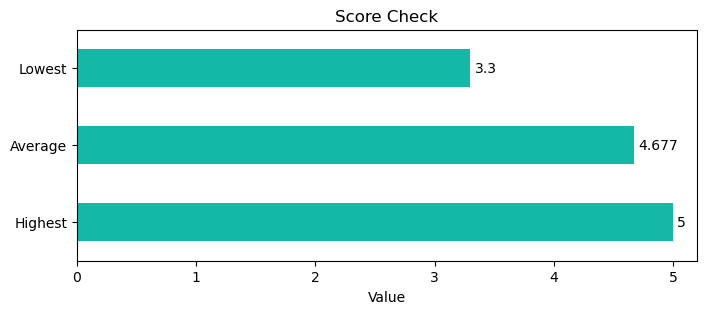

In [9]:
courses["rating"] = pd.to_numeric(courses["rating"], errors="coerce")

score_check = pd.DataFrame(
    {
        "Metric": ["Highest", "Average", "Lowest"],
        "Value": [
            courses["rating"].max(),
            round(courses["rating"].mean(), 3),
            courses["rating"].min(),
        ],
    }
)

ax = score_check.plot(
    kind="barh",
    x="Metric",
    y="Value",
    legend=False,
    color="#14b8a6",
    figsize=(8, 3),
    title="Score Check",
)
ax.set_xlabel("Value")
ax.set_ylabel("")
ax.set_xlim(0, 5.2)
for container in ax.containers:
    ax.bar_label(container, padding=3)

In [10]:
invalid_ratings = courses.loc[
    courses["rating"].isna() | ~courses["rating"].between(0, 5)
]

if invalid_ratings.empty:
    print("Score validation complete: every course is within the expected 0 to 5 scale.")
else:
    print(f"Score validation needs review: {len(invalid_ratings)} rows are outside the expected scale.")

Score validation complete: every course is within the expected 0 to 5 scale.


## Cleaning Step 6: Check Category Values

We check the category columns to confirm that their labels are consistent and easy to compare.

Certificate type labels are consistent.


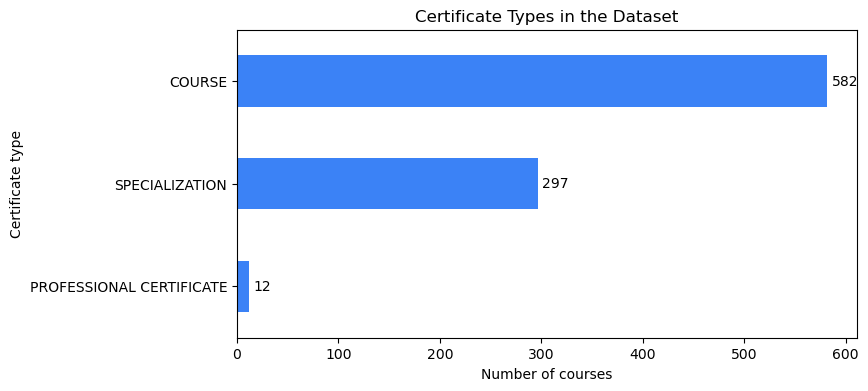

In [11]:
certificate_type_counts = courses["certificate_type"].value_counts().sort_values()

ax = certificate_type_counts.plot(
    kind="barh",
    color="#3b82f6",
    figsize=(8, 4),
    title="Certificate Types in the Dataset",
)
ax.set_xlabel("Number of courses")
ax.set_ylabel("Certificate type")

for container in ax.containers:
    ax.bar_label(container, padding=3)

print("Certificate type labels are consistent.")

Difficulty labels are consistent.


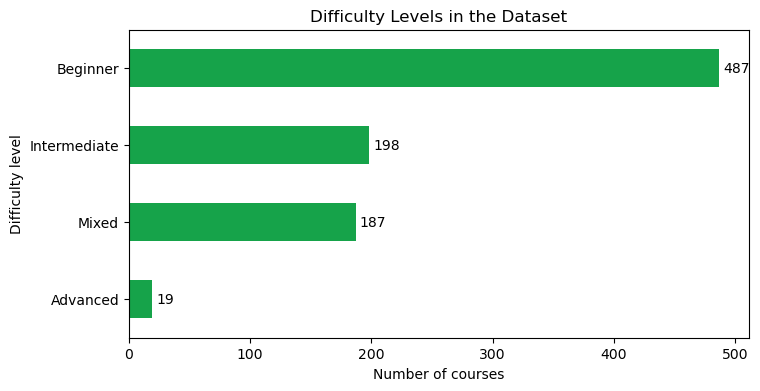

In [12]:
difficulty_counts = courses["difficulty"].value_counts().sort_values()

ax = difficulty_counts.plot(
    kind="barh",
    color="#16a34a",
    figsize=(8, 4),
    title="Difficulty Levels in the Dataset",
)
ax.set_xlabel("Number of courses")
ax.set_ylabel("Difficulty level")

for container in ax.containers:
    ax.bar_label(container, padding=3)

print("Difficulty labels are consistent.")

## Cleaning Step 7: Save and Preview the Cleaned Dataset

In [13]:
cleaned_columns = [
    "course_title",
    "organization",
    "certificate_type",
    "rating",
    "difficulty",
    "students_enrolled",
]

courses_cleaned = courses.loc[:, cleaned_columns].copy()

CLEANED_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
courses_cleaned.to_csv(CLEANED_OUTPUT_PATH, index=False)

print("Preview of the cleaned dataset used for analysis:")
courses_cleaned.head()

Preview of the cleaned dataset used for analysis:


,course_title,organization,certificate_type,rating,difficulty,students_enrolled
0,(ISC)² Systems Security Certified Practitioner...,(ISC)²,SPECIALIZATION,4.7,Beginner,5300
1,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,COURSE,4.7,Intermediate,17000
2,A Crash Course in Data Science,Johns Hopkins University,COURSE,4.5,Mixed,130000
3,A Law Student's Toolkit,Yale University,COURSE,4.7,Mixed,91000
4,A Life of Happiness and Fulfillment,Indian School of Business,COURSE,4.8,Mixed,320000


## Exploratory Data Analysis

This section combines summary tables and charts so each question has both numbers and a visual check.

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

CHART_OUTPUT_DIR = Path("../outputs/charts")
CHART_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cleaned_courses = pd.read_csv(CLEANED_OUTPUT_PATH)
print(f"EDA dataset ready: {cleaned_courses.shape[0]} rows and {cleaned_courses.shape[1]} columns.")

EDA dataset ready: 891 rows and 6 columns.


### Question 1: Which organizations offer the most courses?

We start with course count because it shows which providers are most represented in the dataset.

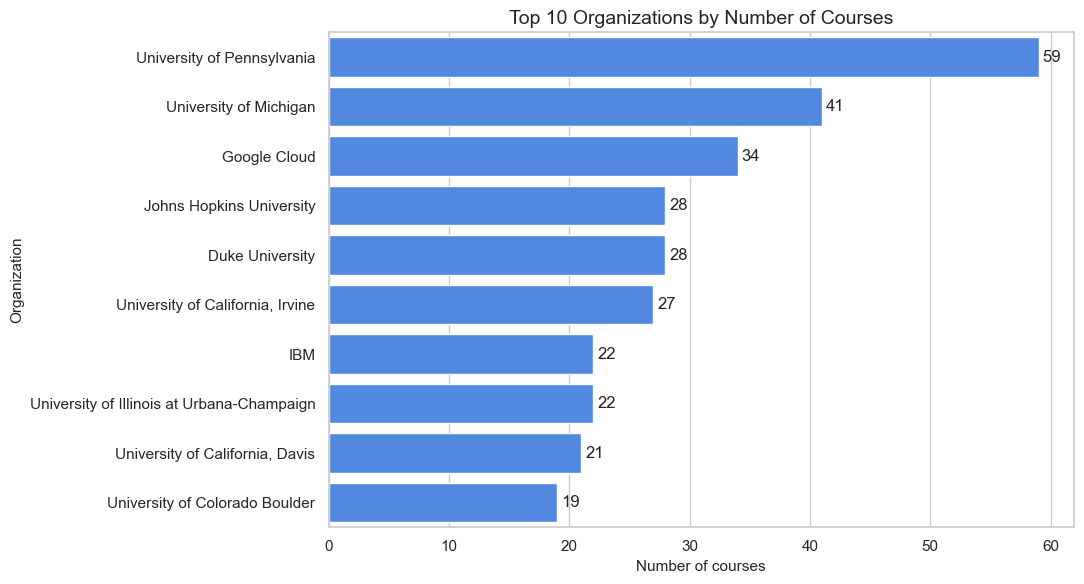

In [15]:
top_organizations = (
    cleaned_courses["organization"]
    .value_counts()
    .head(10)
    .rename_axis("organization")
    .reset_index(name="course_count")
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=top_organizations,
    y="organization",
    x="course_count",
    color="#3b82f6",
    ax=ax,
)
ax.set_title("Top 10 Organizations by Number of Courses")
ax.set_xlabel("Number of courses")
ax.set_ylabel("Organization")
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.tight_layout()
fig.savefig(CHART_OUTPUT_DIR / "top_organizations_by_course_count.png", dpi=150, bbox_inches="tight")
plt.show()

Top provider by count: University of Pennsylvania with 59 courses.

### Question 2: How are courses distributed by certificate type?

This checks whether the dataset is balanced across certificate categories.

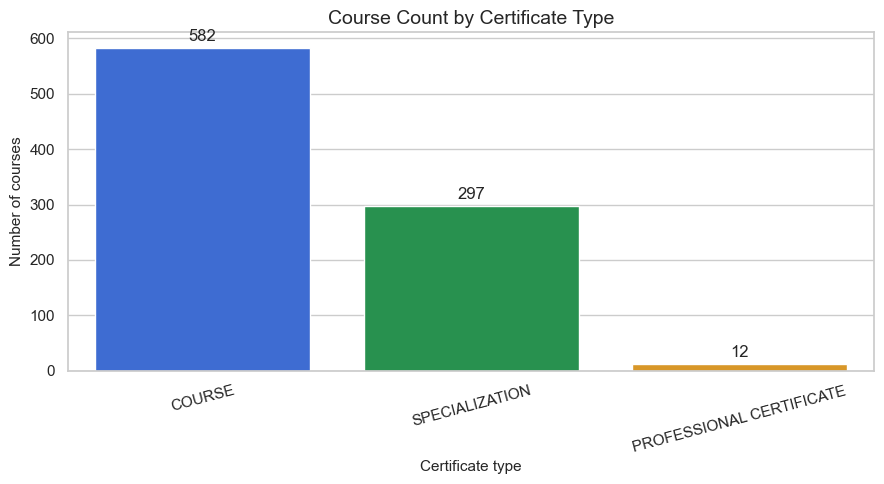

In [16]:
certificate_counts = (
    cleaned_courses["certificate_type"]
    .value_counts()
    .rename_axis("certificate_type")
    .reset_index(name="course_count")
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=certificate_counts,
    x="certificate_type",
    y="course_count",
    hue="certificate_type",
    palette=["#2563eb", "#16a34a", "#f59e0b"],
    legend=False,
    ax=ax,
)
ax.set_title("Course Count by Certificate Type")
ax.set_xlabel("Certificate type")
ax.set_ylabel("Number of courses")
ax.tick_params(axis="x", rotation=15)
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.tight_layout()
fig.savefig(CHART_OUTPUT_DIR / "course_count_by_certificate_type.png", dpi=150, bbox_inches="tight")
plt.show()

Largest certificate category: COURSE with 582 records.

### Question 3: How are ratings distributed overall?

A distribution chart is more useful than only mean or median because it shows whether ratings are spread out or concentrated.

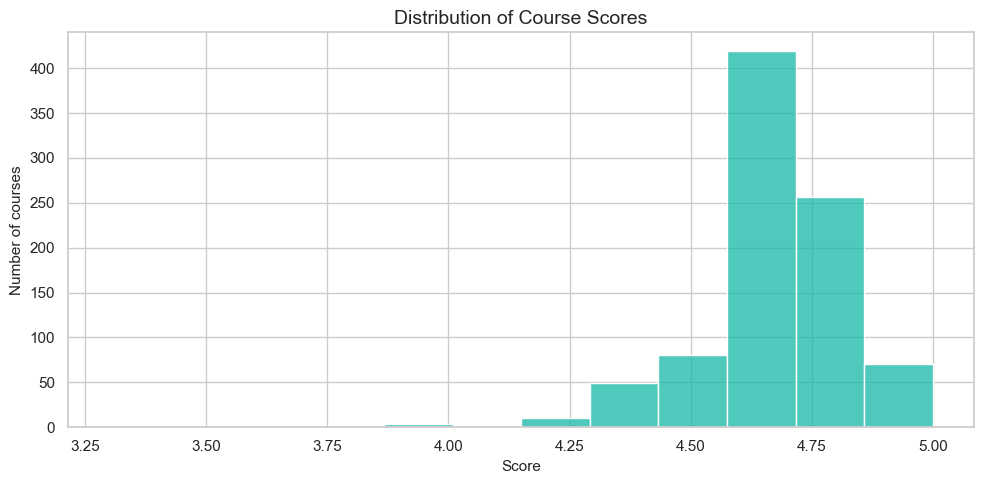

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=cleaned_courses,
    x="rating",
    bins=12,
    color="#14b8a6",
    edgecolor="white",
    ax=ax,
)
ax.set_title("Distribution of Course Scores")
ax.set_xlabel("Score")
ax.set_ylabel("Number of courses")
plt.tight_layout()
fig.savefig(CHART_OUTPUT_DIR / "rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Rating range: 3.3 to 5.0, with most values concentrated near the high end.

### Question 4: How do ratings compare by difficulty?

A boxplot compares the full rating spread, which is better than relying only on mean or median.

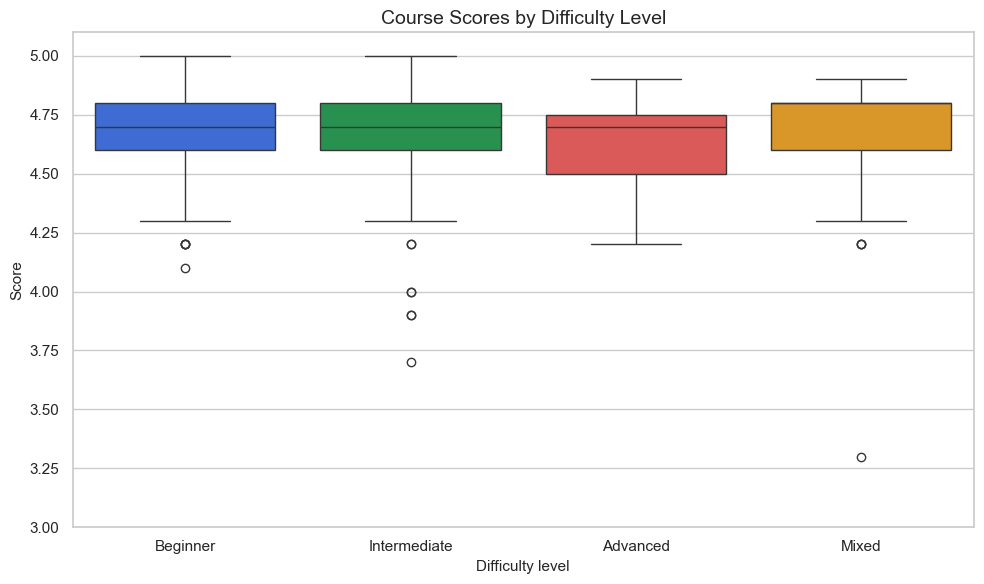

In [18]:
difficulty_order = ["Beginner", "Intermediate", "Advanced", "Mixed"]

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=cleaned_courses,
    x="difficulty",
    y="rating",
    order=difficulty_order,
    hue="difficulty",
    palette=["#2563eb", "#16a34a", "#f59e0b", "#ef4444"],
    legend=False,
    ax=ax,
)
ax.set_title("Course Scores by Difficulty Level")
ax.set_xlabel("Difficulty level")
ax.set_ylabel("Score")
ax.set_ylim(3.0, 5.1)
plt.tight_layout()
fig.savefig(CHART_OUTPUT_DIR / "ratings_by_difficulty.png", dpi=150, bbox_inches="tight")
plt.show()

Highest average rating by difficulty: Mixed at 4.709.

### Question 5: How do ratings compare by certificate type?

The boxplot shows rating spread and outliers for each certificate type.

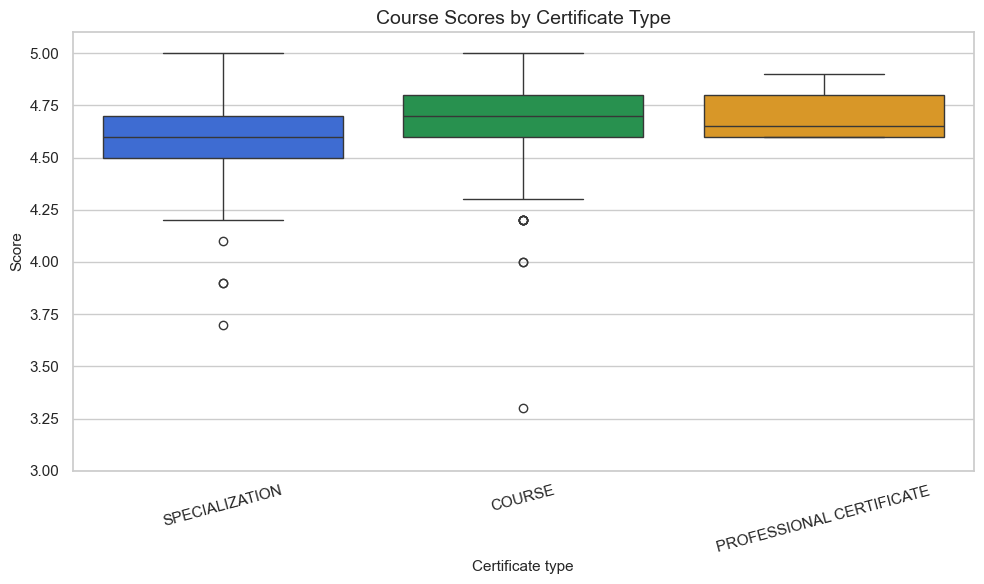

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=cleaned_courses,
    x="certificate_type",
    y="rating",
    hue="certificate_type",
    palette=["#2563eb", "#16a34a", "#f59e0b"],
    legend=False,
    ax=ax,
)
ax.set_title("Course Scores by Certificate Type")
ax.set_xlabel("Certificate type")
ax.set_ylabel("Score")
ax.set_ylim(3.0, 5.1)
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
fig.savefig(CHART_OUTPUT_DIR / "ratings_by_certificate_type.png", dpi=150, bbox_inches="tight")
plt.show()

Highest average rating by certificate type: COURSE at 4.707.

### Question 6: Which courses have the most enrolled students?

This chart highlights the largest courses by enrollment.

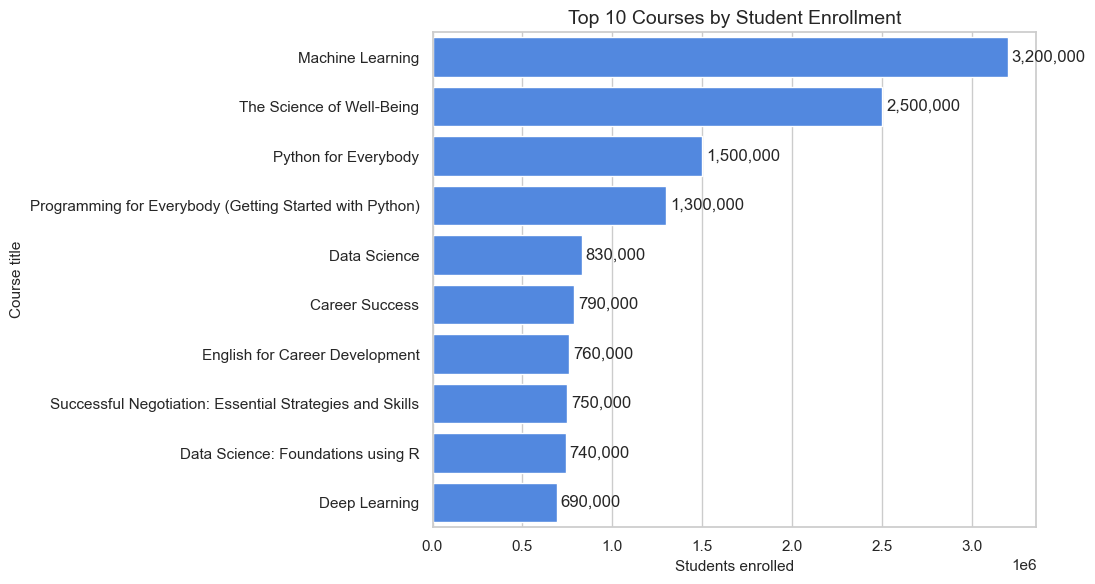

In [20]:
top_enrolled_courses = (
    cleaned_courses
    .sort_values("students_enrolled", ascending=False)
    .loc[:, ["course_title", "students_enrolled"]]
    .head(10)
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=top_enrolled_courses,
    y="course_title",
    x="students_enrolled",
    color="#3b82f6",
    ax=ax,
)
ax.set_title("Top 10 Courses by Student Enrollment")
ax.set_xlabel("Students enrolled")
ax.set_ylabel("Course title")
for container in ax.containers:
    ax.bar_label(container, labels=[f"{v:,.0f}" for v in container.datavalues], padding=3)
plt.tight_layout()
plt.show()

Largest course by enrollment: Stanford University's `Machine Learning` with 3,200,000 students.

### Question 7: Is rating related to enrollment?

A scatterplot checks whether higher-rated courses also tend to have higher enrollment.

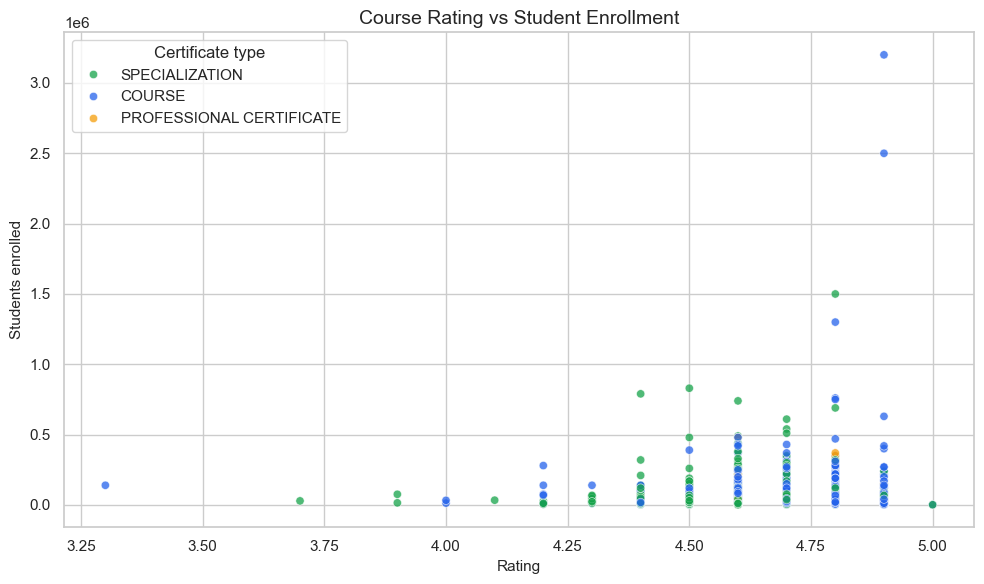

Correlation between rating and enrollment: 0.0711


In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=cleaned_courses,
    x="rating",
    y="students_enrolled",
    hue="certificate_type",
    palette={
        "COURSE": "#2563eb",
        "SPECIALIZATION": "#16a34a",
        "PROFESSIONAL CERTIFICATE": "#f59e0b",
    },
    alpha=0.75,
    ax=ax,
)
ax.set_title("Course Rating vs Student Enrollment")
ax.set_xlabel("Rating")
ax.set_ylabel("Students enrolled")
ax.legend(title="Certificate type")
plt.tight_layout()
fig.savefig(CHART_OUTPUT_DIR / "rating_vs_enrollment.png", dpi=150, bbox_inches="tight")
plt.show()

rating_enrollment_correlation = cleaned_courses["rating"].corr(
    cleaned_courses["students_enrolled"]
)
print(f"Correlation between rating and enrollment: {rating_enrollment_correlation:.4f}")

The correlation is 0.0711, which is very weak.

### Question 8: How does enrollment compare across groups?

Enrollment is skewed, so charts help compare group spread more clearly than average alone.

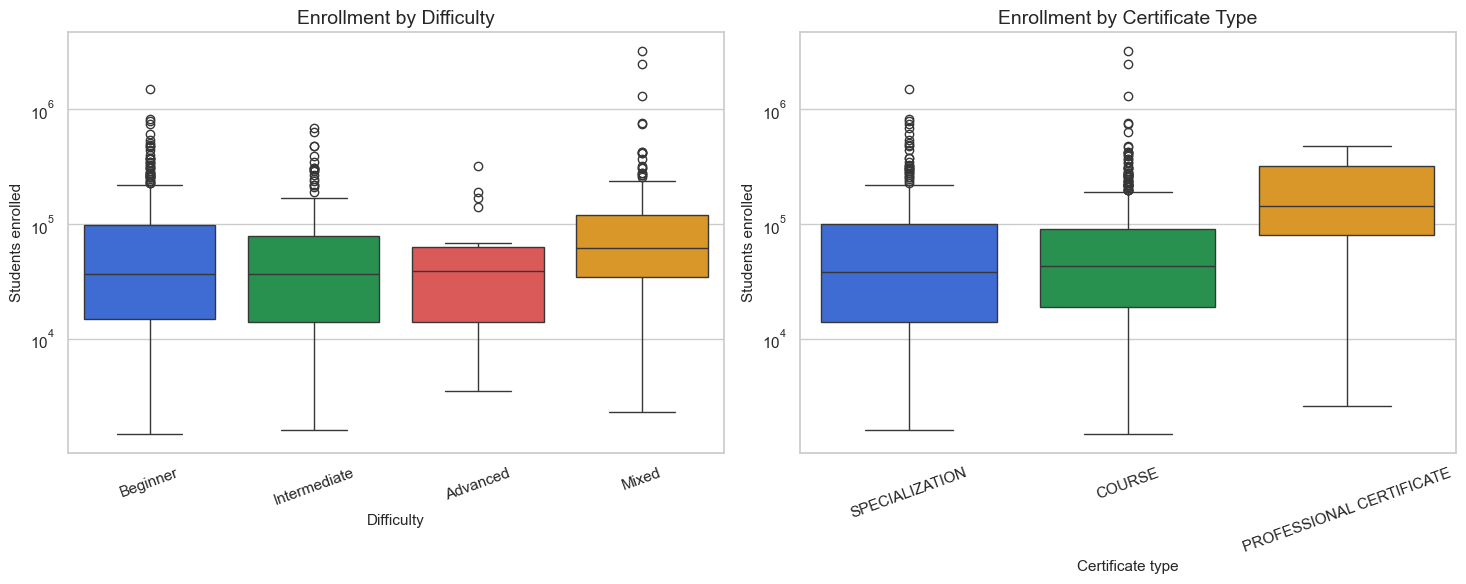

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(
    data=cleaned_courses,
    x="difficulty",
    y="students_enrolled",
    order=difficulty_order,
    hue="difficulty",
    palette=["#2563eb", "#16a34a", "#f59e0b", "#ef4444"],
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Enrollment by Difficulty")
axes[0].set_xlabel("Difficulty")
axes[0].set_ylabel("Students enrolled")
axes[0].set_yscale("log")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(
    data=cleaned_courses,
    x="certificate_type",
    y="students_enrolled",
    hue="certificate_type",
    palette=["#2563eb", "#16a34a", "#f59e0b"],
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Enrollment by Certificate Type")
axes[1].set_xlabel("Certificate type")
axes[1].set_ylabel("Students enrolled")
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [23]:
mixed_median_enrollment = int(
    cleaned_courses.loc[
        cleaned_courses["difficulty"] == "Mixed", "students_enrolled"
    ].median()
)

print(f"Highest median enrollment by difficulty: Mixed with {mixed_median_enrollment:,} students.")

Highest median enrollment by difficulty: Mixed with 62,000 students.


Highest median enrollment by difficulty: Mixed with 62,000 students.

## Limitations

Every dataset has limits. Naming them is part of honest analysis.

- The dataset does not include course publish dates, so we cannot tell whether older courses have more students because they have had more time to grow.
- The dataset does not include course subject categories, so we cannot compare fields like data science, business, health, or arts.
- Enrollment appears as rounded public values, such as `5.3k`, so the numeric enrollment column is an estimate based on those rounded values.
- Ratings are highly concentrated between 4.5 and 5.0, so small rating differences should not be overinterpreted.
- Professional certificates have only 12 records, so conclusions about that group are less stable than conclusions about regular courses or specializations.

## Suggestions for Improvement

- Add course subject categories to compare topics such as data science, business, health, and arts.
- Add course launch dates to separate older course popularity from current demand.
- Add review counts because a rating based on many reviews is stronger evidence than one based on few reviews.
- Compare organizations by median enrollment, not only number of courses.
- Use course-title text analysis to identify common themes such as Python, machine learning, and business.